## K-Nearest Neighbors (KNN) Definition

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for classification and regression.

It works by finding the 'K' closest data points (neighbors) to a given input and making predictions based on their majority class (for classification) or average value (for regression).

K is a hyperparameter that determines how many neighbors are considered.

Key points:
- It is a non-parametric and instance-based learning algorithm.
- It uses distance metrics like Euclidean or Manhattan distance.
- Smaller K can lead to overfitting, while larger K can lead to underfitting.

In [1]:
# importing major libraries

import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('Cancer_Data.csv').drop(['id','Unnamed: 32'],axis=1)

In [3]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
df.columns

df.diagnosis.value_counts().index

df.diagnosis = df.diagnosis.map({'B':0, 'M':1})

In [5]:
x = df.iloc[:,1:]
y = df.diagnosis

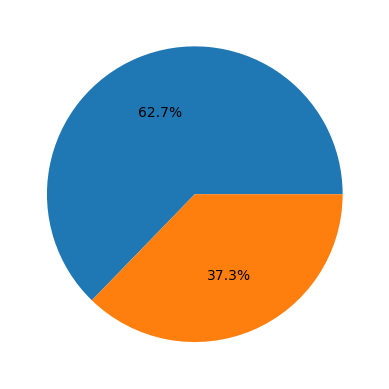

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.pie(df.diagnosis.value_counts(),autopct='%1.1f%%')
plt.show()

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=1,test_size=0.2)
knn = KNeighborsClassifier(n_neighbors=5)
knn

KNeighborsClassifier()

In [8]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [9]:
from sklearn.metrics import accuracy_score,recall_score
y_pred = knn.predict(x_test)
print('accuracy ',accuracy_score(y_test,y_pred)*100)
print('recall ',recall_score(y_test,y_pred)*100)

accuracy  93.85964912280701
recall  88.09523809523809


# Drawback

1. Slow on Large datasets
2. Sensitive towards outliers
3. Curse of Dimensionality
4. Feature Scaling --> standard scaler
5. Choosing k Value is difficult
  - K(BIG) --> UNDERFIT
  - K(SMALL) --> OVERFIT
6. EXPENSIVE

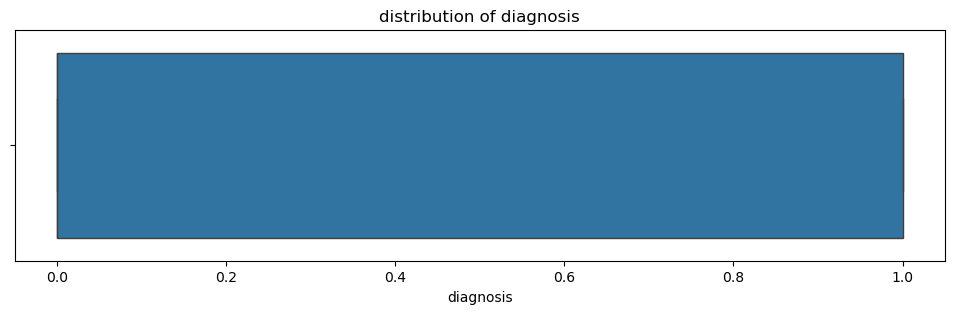

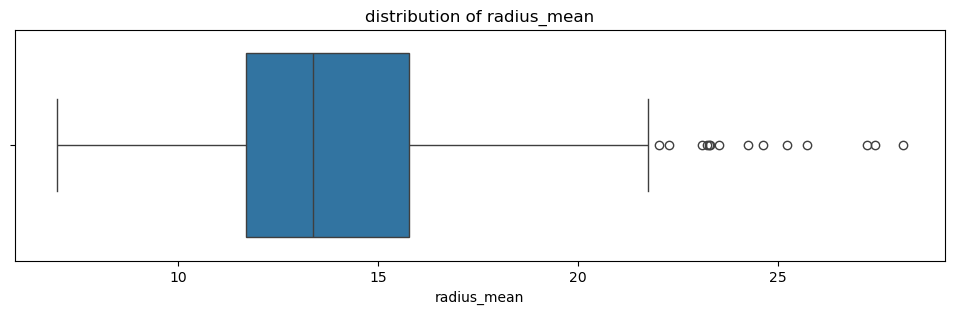

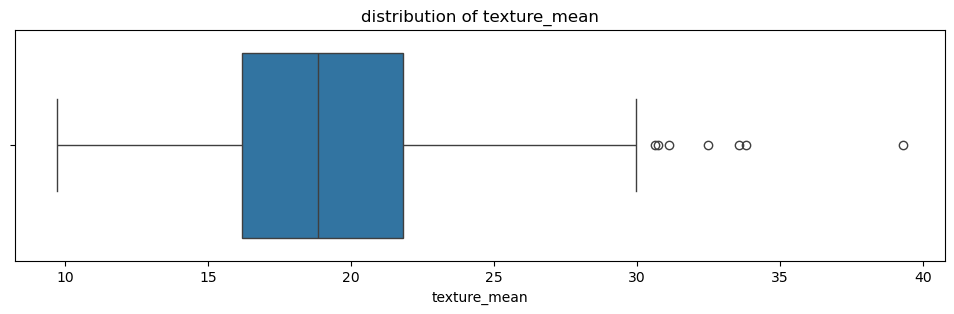

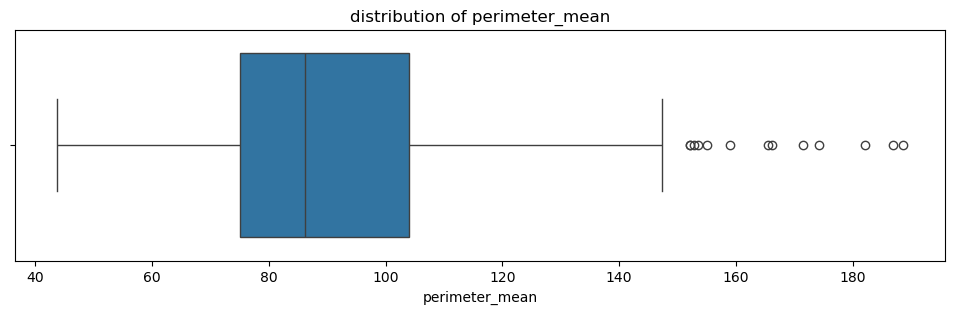

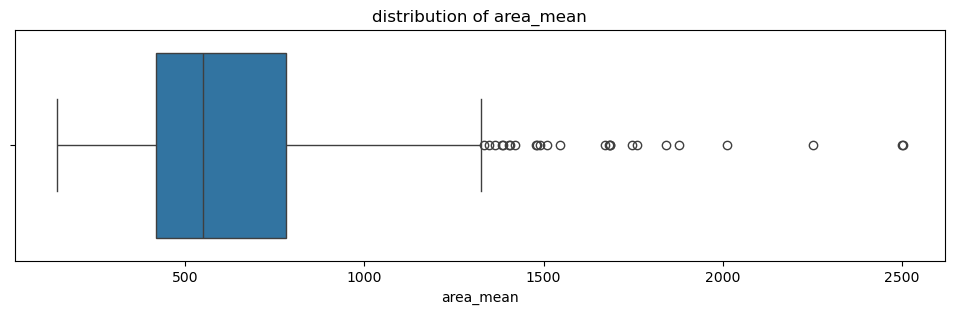

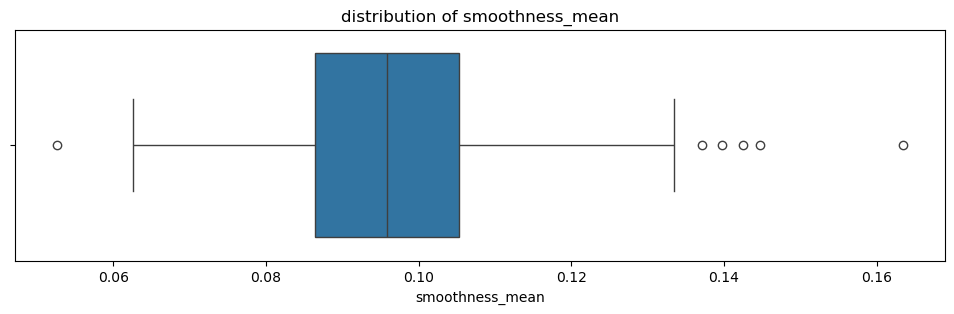

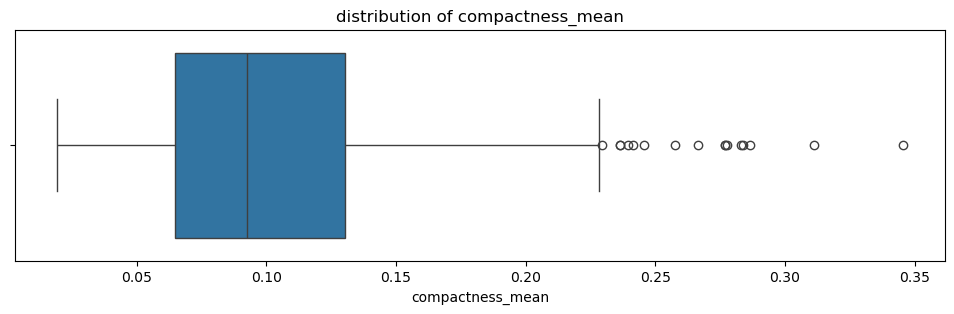

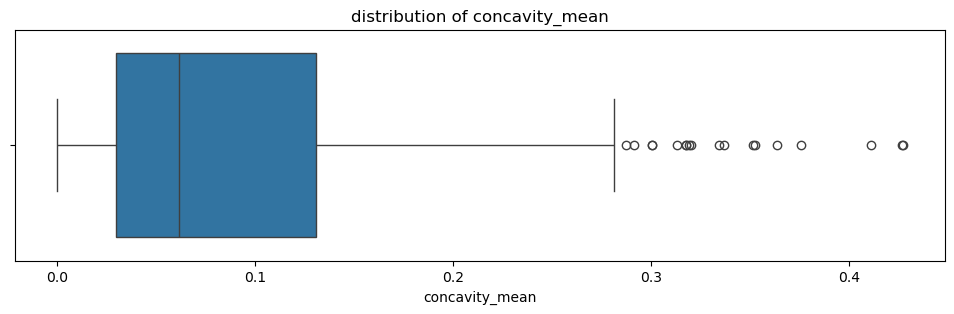

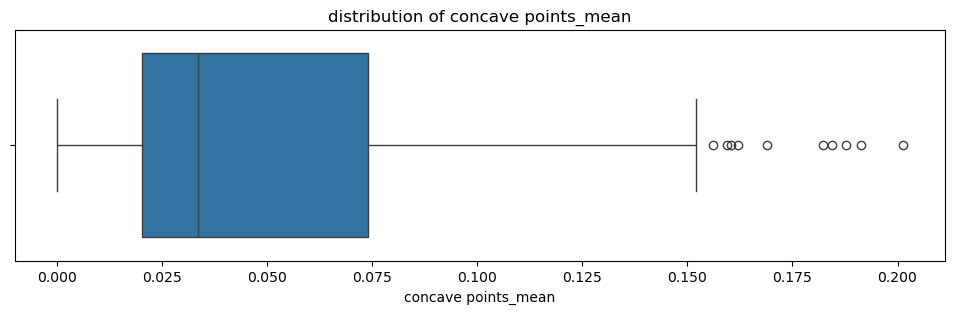

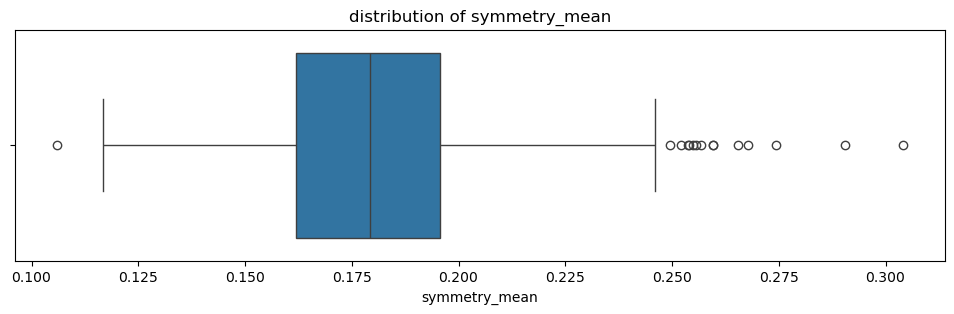

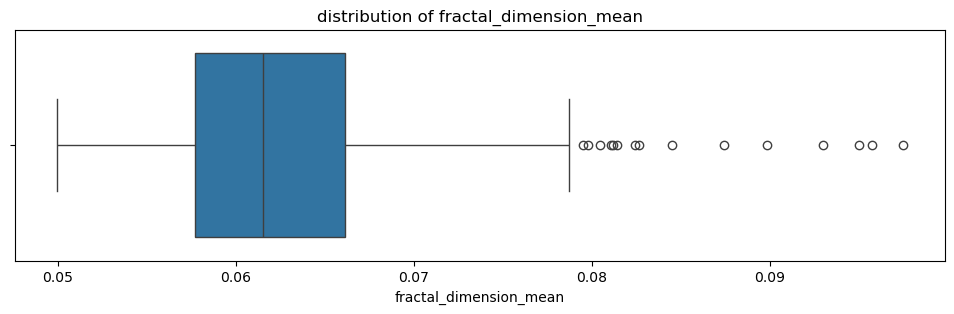

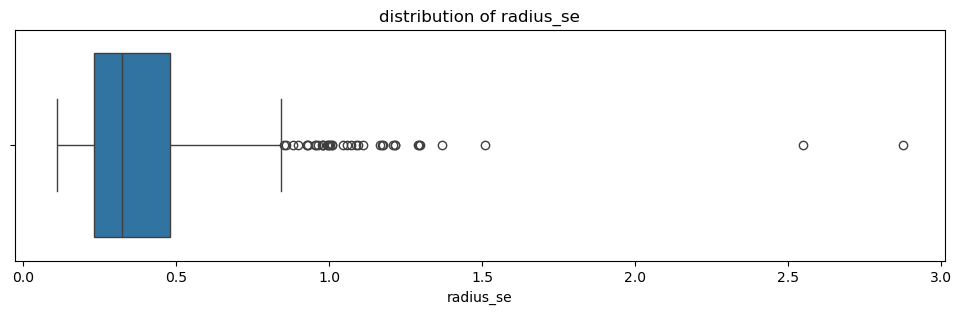

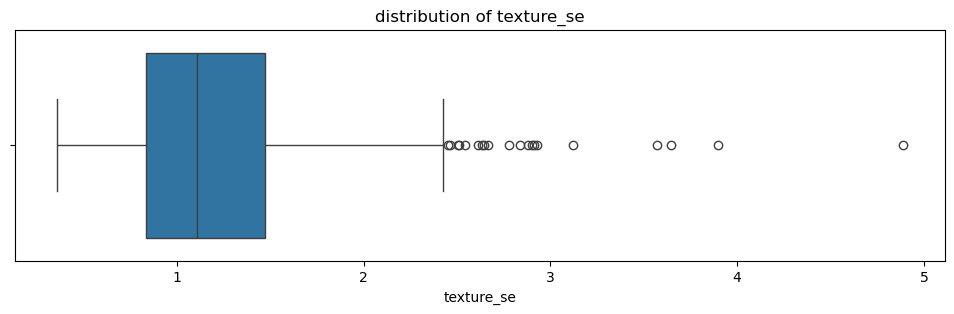

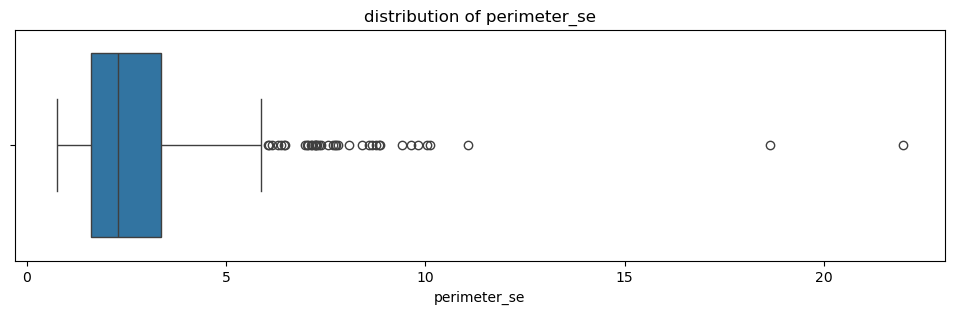

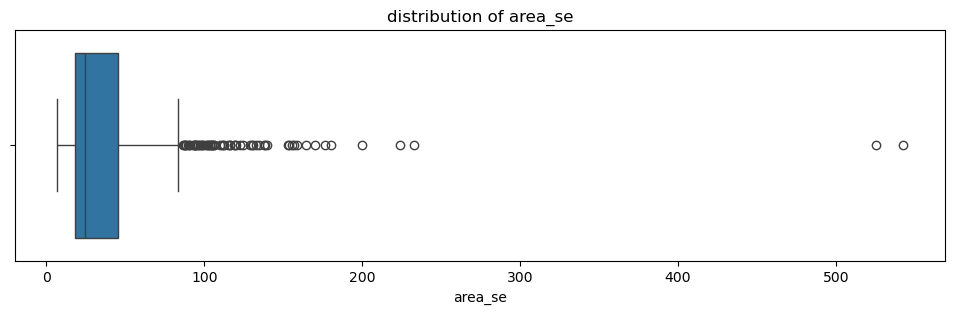

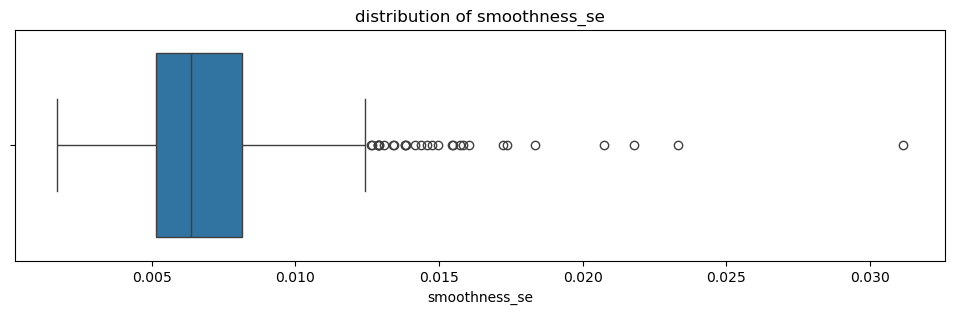

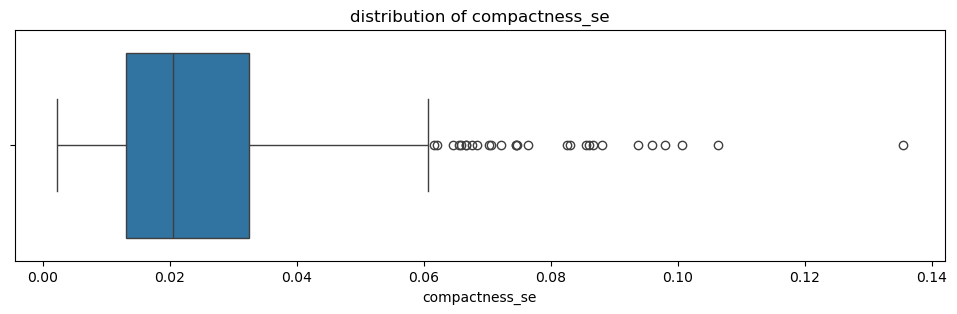

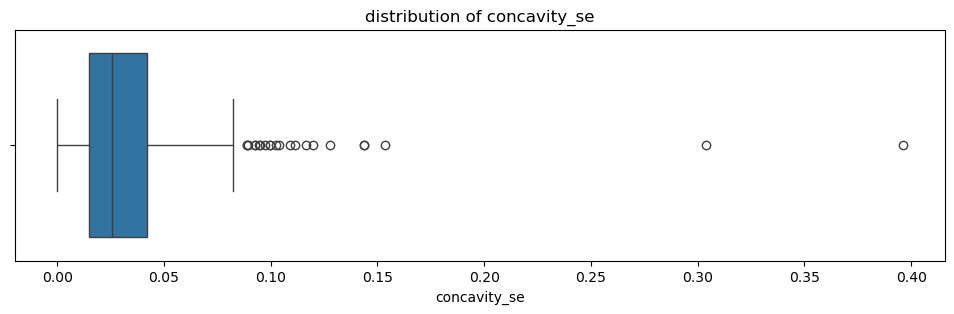

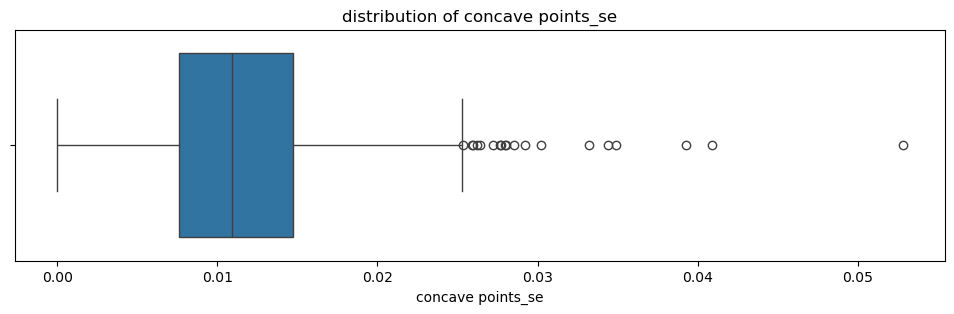

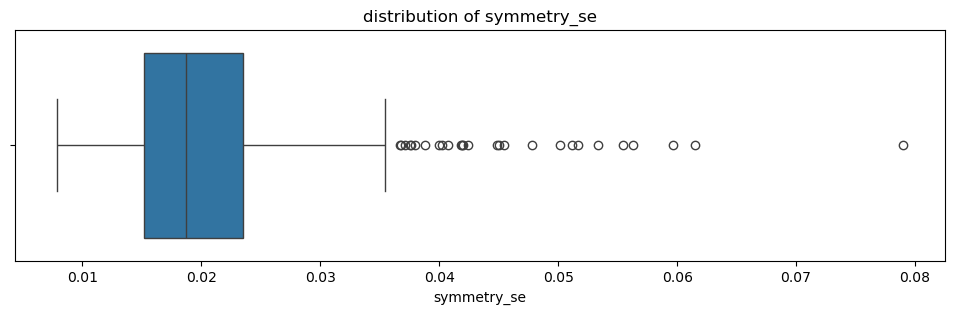

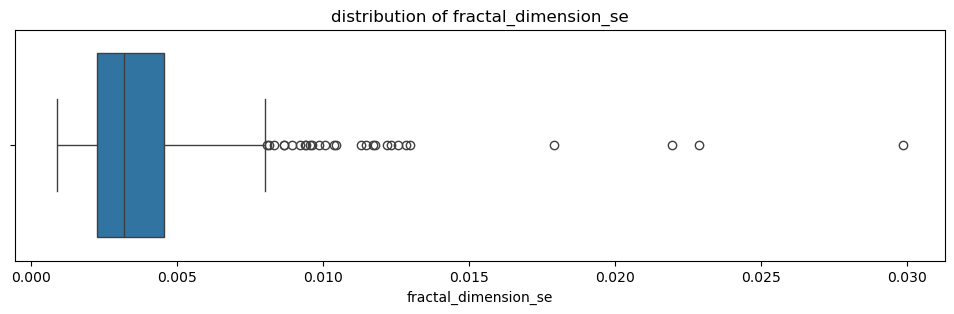

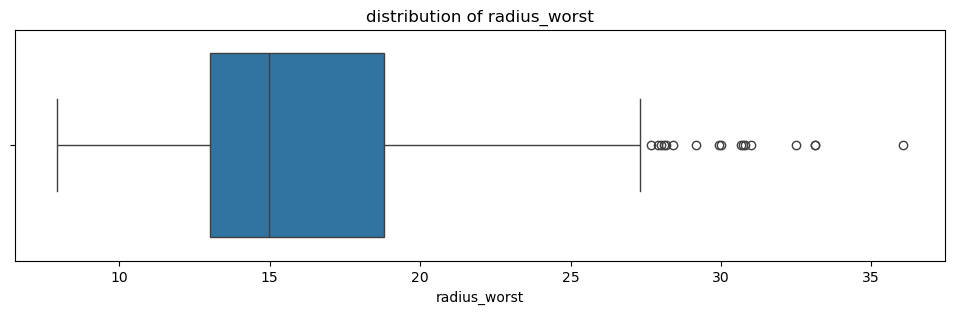

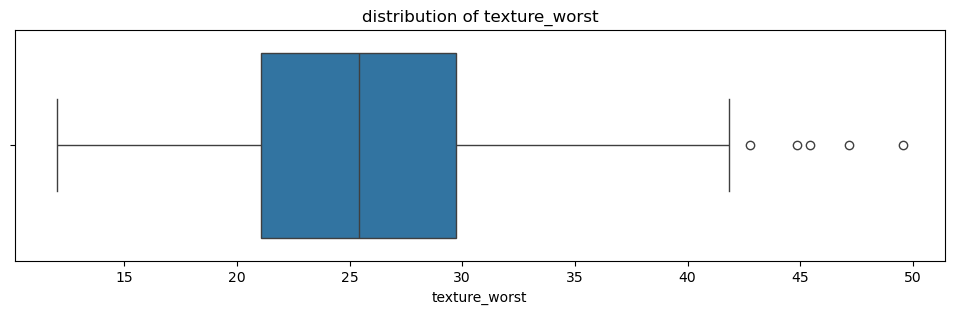

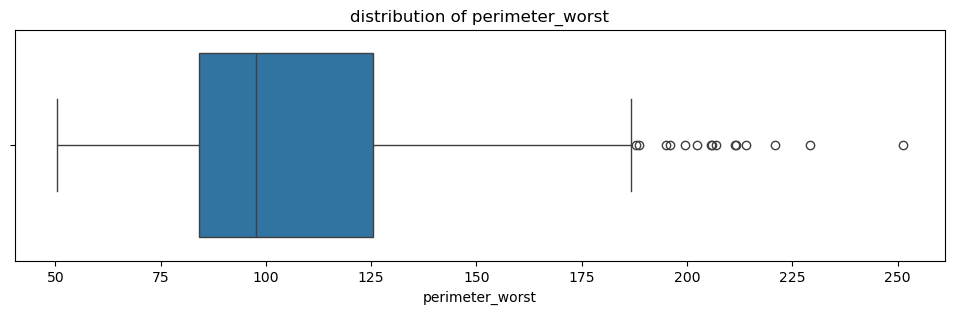

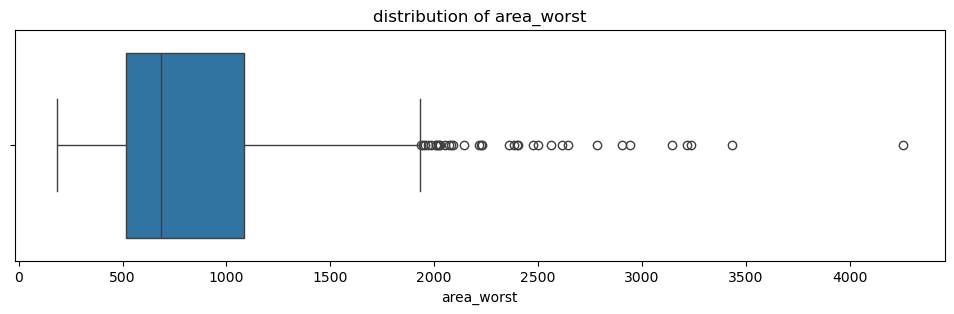

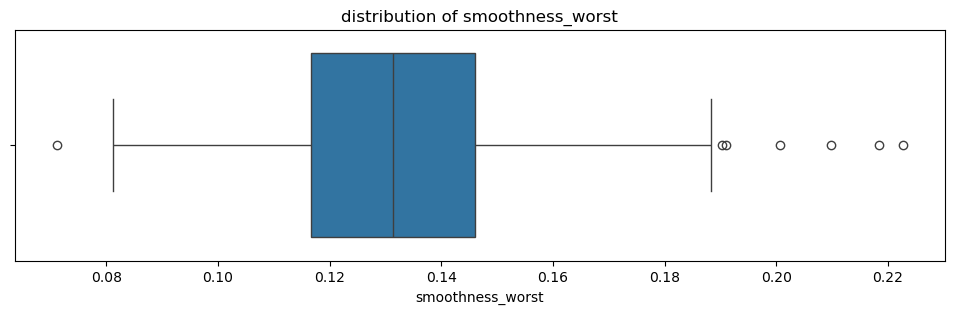

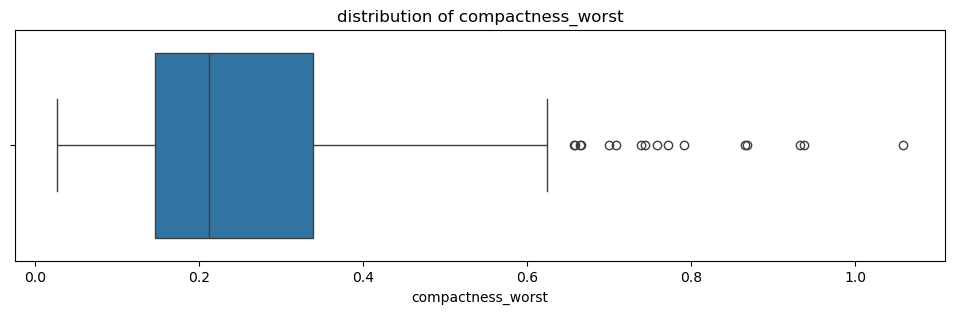

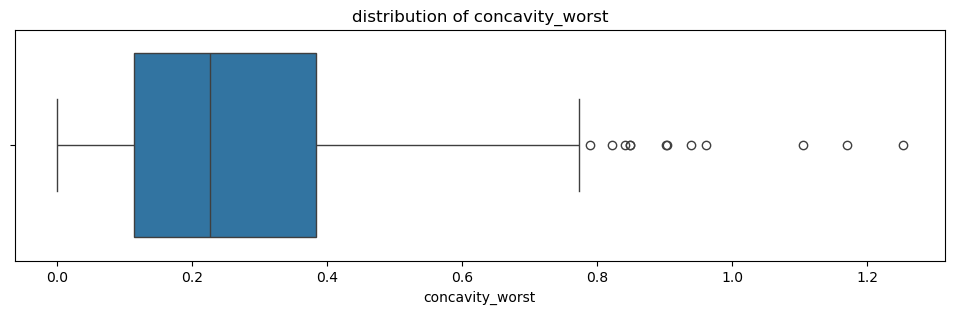

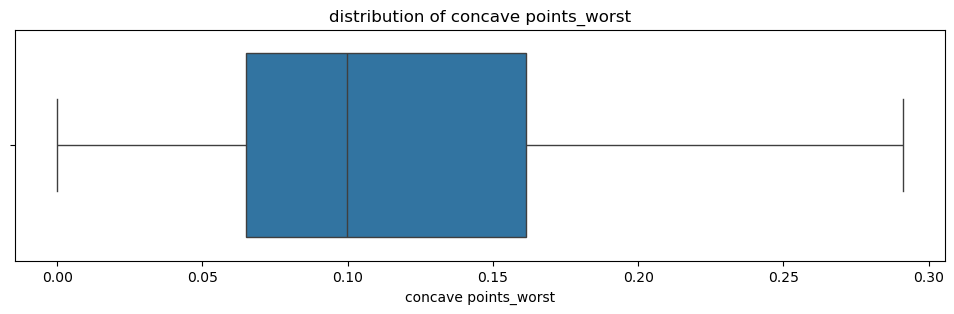

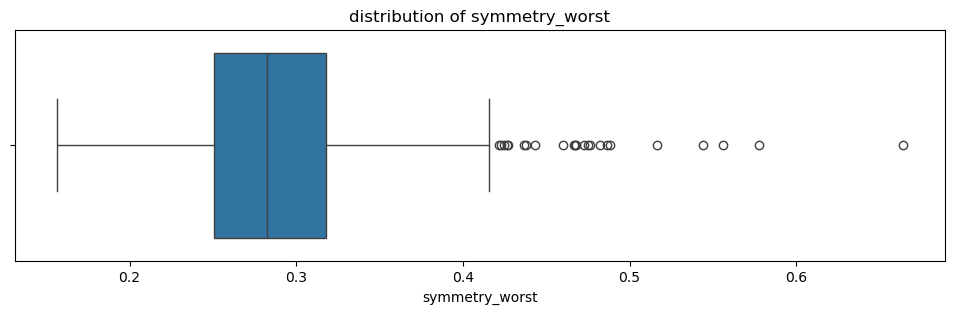

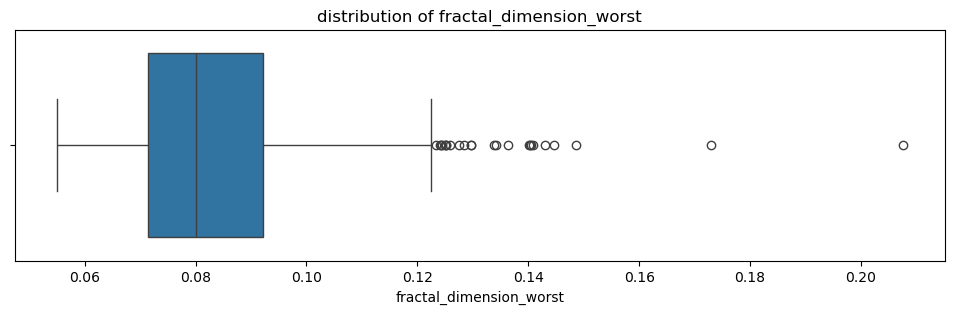

In [10]:
df
import seaborn as sns
import matplotlib.pyplot as plt

for i in df.columns:
    #print(i)
    plt.figure(figsize=(12,3))
    sns.boxplot(x=df[i])
    plt.title(f'distribution of {i}')
    plt.show()

In [11]:
# 1,10,20,30,1000

from sklearn.preprocessing import RobustScaler

rs = RobustScaler()
x_train_scaled = rs.fit_transform(x_train)
x_test_scaled = rs.transform(x_test)

In [12]:
x_train_scaled = pd.DataFrame(x_train_scaled,columns=rs.get_feature_names_out())
x_test_scaled= pd.DataFrame(x_test_scaled,columns=rs.get_feature_names_out())

In [13]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=15,weights='distance',algorithm='brute',n_jobs=-1)  # in algo you take auto
knn.fit(x_train_scaled,y_train)
knn.score(x_test_scaled,y_test)

0.9649122807017544

In [14]:
knn

KNeighborsClassifier(algorithm='brute', n_jobs=-1, n_neighbors=15,
                     weights='distance')

In [15]:
x_train_scaled.describe().round()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,455.0,455.0,455.0,455.0,455.0,455.0,455.0,455.0,455.0,455.0,...,455.0,455.0,455.0,455.0,455.0,455.0,455.0,455.0,455.0,455.0
mean,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
min,-1.0,-2.0,-1.0,-1.0,-2.0,-1.0,-1.0,-1.0,-2.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-2.0,-1.0,-1.0,-1.0,-2.0,-1.0
25%,-0.0,-0.0,-0.0,-0.0,-1.0,-0.0,-0.0,-0.0,-1.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-1.0,-0.0,-0.0,-0.0,-0.0,-0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,...,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
max,3.0,4.0,3.0,5.0,4.0,4.0,4.0,3.0,4.0,4.0,...,3.0,3.0,4.0,6.0,3.0,4.0,3.0,2.0,5.0,3.0


In [16]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('scale',RobustScaler()),
    ('estimator',KNeighborsClassifier(n_neighbors=15,weights='distance',algorithm='brute',n_jobs=-1))
])
pipe

Pipeline(steps=[('scale', RobustScaler()),
                ('estimator',
                 KNeighborsClassifier(algorithm='brute', n_jobs=-1,
                                      n_neighbors=15, weights='distance'))])

In [17]:
pipe.fit(x_train,y_train)
from sklearn.metrics import accuracy_score,recall_score
print(accuracy_score(y_test,pipe.predict(x_test))*100)
print(recall_score(y_test,pipe.predict(x_test))*100)

96.49122807017544
90.47619047619048


In [18]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [19]:
import joblib 
joblib.dump(pipe,'knn_pipe.pk1')


['knn_pipe.pk1']

In [20]:
joblib.load('knn_pipe.pk1')

Pipeline(steps=[('scale', RobustScaler()),
                ('estimator',
                 KNeighborsClassifier(algorithm='brute', n_jobs=-1,
                                      n_neighbors=15, weights='distance'))])